<a href="https://colab.research.google.com/github/sabuj10h/Machine-learning-practice-/blob/main/client_sepa2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ============================================================
# USED CAR PRICE PREDICTION
# Machine Learning Regression Project
# ============================================================

# -----------------------------
# 1. Import Libraries
# -----------------------------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [ ]:
# -----------------------------
# 2. Load Dataset
# -----------------------------

df = pd.read_csv("/content/used_car_price_prediction_practice.csv")


print("***USED CAR PRICE PREDICTION***")


print("\nFirst 5 rows:")
display(df.head())





***USED CAR PRICE PREDICTION***

First 5 rows:


,Car_ID,Brand,Model,Year,Mileage_km,Fuel_Type,Transmission,Engine_CC,Owner_Count,Accident_History,Service_History,Location,Seller_Type,Price_Lakh
0,10001,Ford,Mustang,2013,58151.0,Petrol,Automatic,2000.0,2,No,Partial,Rajshahi,Individual,8.11
1,10002,BMW,3 Series,2019,116755.0,Petrol,Automatic,3000.0,4,No,Full,Khulna,Dealer,30.89
2,10003,Mercedes,GLC,2009,51176.0,Petrol,Automatic,1300.0,1,No,Partial,Sylhet,Dealer,34.17
3,10004,Ford,Focus,2014,85137.0,Hybrid,Manual,1600.0,2,Yes,Partial,Chattogram,Individual,4.00
4,10005,Nissan,Sunny,2023,90448.0,Hybrid,Manual,1300.0,3,No,Partial,Dhaka,Dealer,11.60


In [ ]:
# -----------------------------
# 3. Basic Data Understanding
# -----------------------------

print("\n***DATASET INFORMATION***")


print("\nDataset shape:", df.shape)

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

print("\nSummary statistics:")
display(df.describe())



***DATASET INFORMATION***

Dataset shape: (1808, 14)

Data types:
Car_ID                int64
Brand                object
Model                object
Year                  int64
Mileage_km          float64
Fuel_Type            object
Transmission         object
Engine_CC           float64
Owner_Count           int64
Accident_History     object
Service_History      object
Location             object
Seller_Type          object
Price_Lakh          float64
dtype: object

Missing values:
Car_ID                0
Brand                 0
Model                 0
Year                  0
Mileage_km            7
Fuel_Type             0
Transmission          0
Engine_CC            10
Owner_Count           0
Accident_History      0
Service_History     179
Location              0
Seller_Type           0
Price_Lakh            0
dtype: int64

Duplicate rows:
8

Summary statistics:


,Car_ID,Year,Mileage_km,Engine_CC,Owner_Count,Price_Lakh
count,1808.000000,1808.000000,1801.000000,1798.000000,1808.000000,1808.000000
mean,10900.361173,2016.612279,65018.976680,1820.133482,1.710177,18.880476
std,519.919240,5.193926,32886.295885,590.233614,0.881505,15.039127
min,10001.000000,2008.000000,3000.000000,1000.000000,1.000000,4.000000
25%,10449.750000,2012.000000,42062.000000,1300.000000,1.000000,4.862500
50%,10900.500000,2017.000000,64577.000000,1800.000000,1.000000,14.880000
75%,11350.250000,2021.000000,87158.000000,2200.000000,2.000000,27.557500
max,11800.000000,2025.000000,193020.000000,3000.000000,4.000000,66.330000


In [ ]:
# -----------------------------
# 4. Remove Duplicate Rows
# -----------------------------

df=df.drop_duplicates()
print("\nNew shape after removed.",df.shape)



New shape after removed. (1800, 14)



EXPLORATORY DATA ANALYSIS


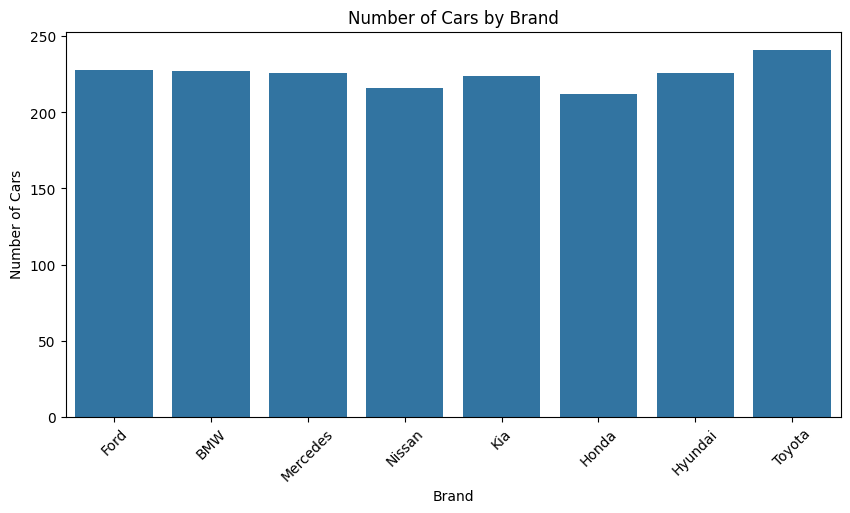

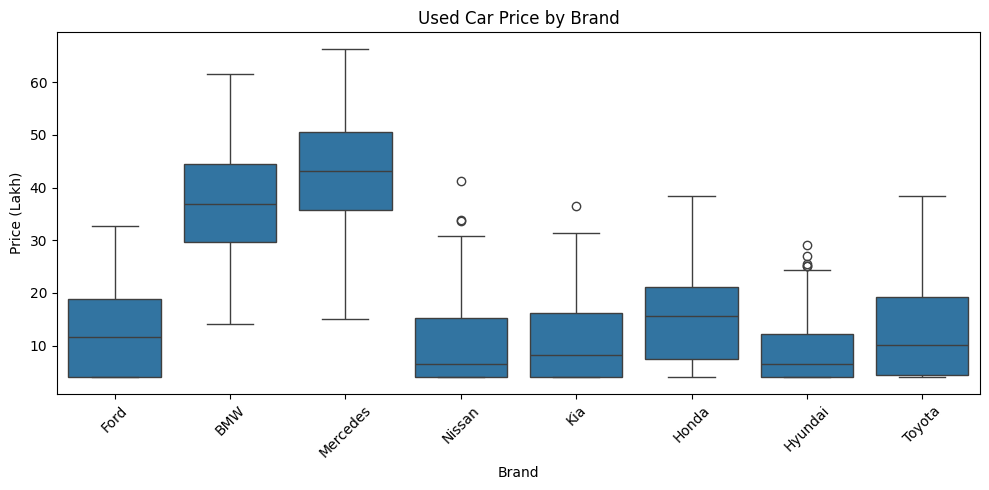

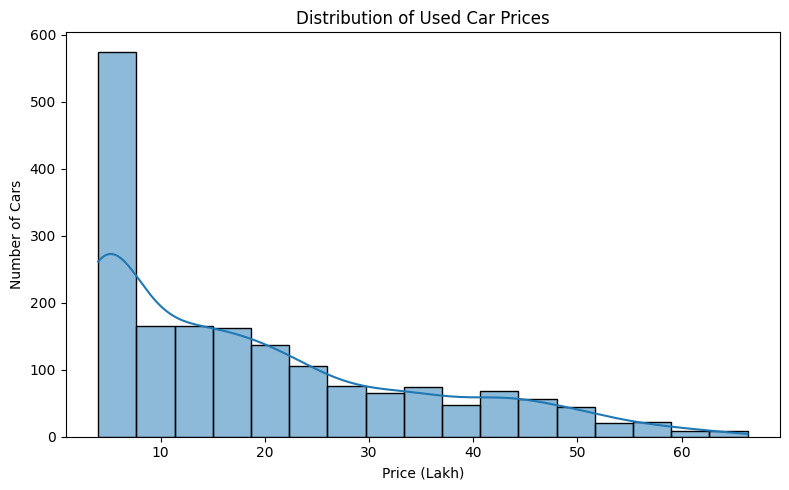

In [ ]:
# -----------------------------
# 5. Exploratory Data Analysis
# -----------------------------

print("\n" + "=" * 60)
print("EXPLORATORY DATA ANALYSIS")
print("=" * 60)

# Number of cars by brand
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x="Brand")
plt.xticks(rotation=45)
plt.title("Number of Cars by Brand")
plt.xlabel("Brand")
plt.ylabel("Number of Cars")
plt.show()


# Price distribution by brand
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x="Brand", y="Price_Lakh")
plt.xticks(rotation=45)
plt.title("Used Car Price by Brand")
plt.xlabel("Brand")
plt.ylabel("Price (Lakh)")
plt.tight_layout()
plt.show()


# Price distribution
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="Price_Lakh", kde=True)
plt.title("Distribution of Used Car Prices")
plt.xlabel("Price (Lakh)")
plt.ylabel("Number of Cars")
plt.tight_layout()
plt.show()


In [ ]:
# -----------------------------
# 6. Define Features and Target
# -----------------------------

X = df.drop(columns=["Price_Lakh", "Car_ID"])
y = df["Price_Lakh"]

print("\n" + "=" * 60)
print("FEATURES AND TARGET")
print("=" * 60)

print("Target variable: Price_Lakh")
print("Number of features:", X.shape[1])


FEATURES AND TARGET
Target variable: Price_Lakh
Number of features: 12


In [ ]:
# -----------------------------
# 7. Train-Test Split
# -----------------------------

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=0)
print("\nX_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)


X_train shape: (1440, 12)
X_test shape: (360, 12)
y_train shape: (1440,)
y_test shape: (360,)


In [ ]:
# -----------------------------
# 8. Identify Feature Types
# -----------------------------

numeric_features = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X_train.select_dtypes(include=["object"]).columns.tolist()

print("\nNumeric features:", numeric_features)
print("Categorical features:", categorical_features)



Numeric features: ['Year', 'Mileage_km', 'Engine_CC', 'Owner_Count']
Categorical features: ['Brand', 'Model', 'Fuel_Type', 'Transmission', 'Accident_History', 'Service_History', 'Location', 'Seller_Type']


In [ ]:
# -----------------------------
# 9. Preprocessing Pipeline
# -----------------------------

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))])

preprocessor = ColumnTransformer([
    ("numeric", numeric_transformer, numeric_features),
    ("categorical", categorical_transformer, categorical_features)])

In [ ]:
# -----------------------------
# 10. Define Machine Learning Models
# -----------------------------

models = {
    "Linear Regression": Pipeline([
        ("preprocessor", preprocessor),
        ("model", LinearRegression())]),

    "Decision Tree": Pipeline([
        ("preprocessor", preprocessor),
        ("model", DecisionTreeRegressor(
            max_depth=5,
            random_state=0 ))]),

    "Random Forest": Pipeline([
        ("preprocessor", preprocessor),
        ("model", RandomForestRegressor(
            n_estimators=100,
            random_state=0,
            n_jobs=-1 ))])
}

In [ ]:
# -----------------------------
# 11. Train and Evaluate Models
# -----------------------------

results = []

print("\n" + "=" * 60)
print("MODEL EVALUATION")
print("=" * 60)

for name, model in models.items():

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    results.append({"Model": name,"MAE": mae,"MSE": mse,"RMSE": rmse,"R² Score": r2})

results_df = pd.DataFrame(results)

display(round(results_df),3)


MODEL EVALUATION


,Model,MAE,MSE,RMSE,R² Score
0,Linear Regression,3.0,14.0,4.0,1.0
1,Decision Tree,5.0,42.0,7.0,1.0
2,Random Forest,3.0,22.0,5.0,1.0


3

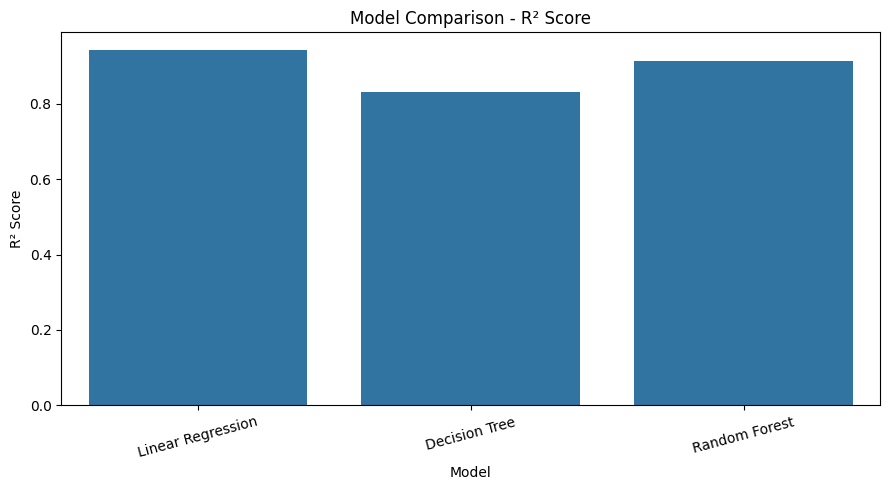

In [ ]:
# -----------------------------
# 12. Compare Model Performance
# -----------------------------

plt.figure(figsize=(9, 5))

sns.barplot(
    data=results_df,
    x="Model",
    y="R² Score"
)

plt.title("Model Comparison - R² Score")
plt.xlabel("Model")
plt.ylabel("R² Score")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

In [ ]:
# -----------------------------
# 13. Cross Validation
# -----------------------------

print("\n" + "=" * 60)
print("5-FOLD CROSS VALIDATION")
print("=" * 60)

rf_model = models["Random Forest"]

cv_scores = cross_val_score(
    rf_model,
    X_train,
    y_train,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

print("Cross-validation R² scores:")
print(np.round(cv_scores, 3))

print("\nMean CV R² Score:", round(cv_scores.mean(), 3))


5-FOLD CROSS VALIDATION
Cross-validation R² scores:
[0.889 0.906 0.888 0.893 0.887]

Mean CV R² Score: 0.893


In [ ]:
# -----------------------------
# 14. Hyperparameter Tuning
# -----------------------------

print("\n" + "=" * 60)
print("DECISION TREE HYPERPARAMETER TUNING")
print("=" * 60)

dt_model = models["Decision Tree"]

param_grid = {
    "model__max_depth": [3, 5, 7, 10, None],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4]
}

grid_search = GridSearchCV(
    estimator=dt_model,
    param_grid=param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best parameters:")
print(grid_search.best_params_)

print("\nBest CV R² Score:")
print(round(grid_search.best_score_, 3))



DECISION TREE HYPERPARAMETER TUNING
Best parameters:
{'model__max_depth': 10, 'model__min_samples_leaf': 4, 'model__min_samples_split': 10}

Best CV R² Score:
0.836


In [ ]:
# -----------------------------
# 15. Evaluate Tuned Decision Tree
# -----------------------------

tuned_dt = grid_search.best_estimator_

y_pred_tuned_dt = tuned_dt.predict(X_test)

tuned_mae = mean_absolute_error(y_test, y_pred_tuned_dt)
tuned_mse = mean_squared_error(y_test, y_pred_tuned_dt)
tuned_rmse = np.sqrt(tuned_mse)
tuned_r2 = r2_score(y_test, y_pred_tuned_dt)

print("\nTuned Decision Tree Test Performance:")
print("MAE:", round(tuned_mae, 2))
print("MSE:", round(tuned_mse, 2))
print("RMSE:", round(tuned_rmse, 2))
print("R² Score:", round(tuned_r2, 3))



Tuned Decision Tree Test Performance:
MAE: 4.36
MSE: 35.19
RMSE: 5.93
R² Score: 0.859


In [ ]:
# -----------------------------
# 16. Select Best Model
# -----------------------------

# Add tuned Decision Tree to model comparison
tuned_result = pd.DataFrame([{
    "Model": "Tuned Decision Tree",
    "MAE": tuned_mae,
    "MSE": tuned_mse,
    "RMSE": tuned_rmse,
    "R² Score": tuned_r2
}])

final_results = pd.concat(
    [results_df, tuned_result],
    ignore_index=True
)

# Higher R² is better
best_model_name = final_results.loc[
    final_results["R² Score"].idxmax(),
    "Model"
]

print("\n" + "=" * 60)
print("BEST MODEL")
print("=" * 60)

print("Best Model:", best_model_name)



BEST MODEL
Best Model: Linear Regression


In [ ]:
# -----------------------------
# 17. Select Final Model
# -----------------------------

if best_model_name == "Tuned Decision Tree":

    final_model = tuned_dt

else:

    final_model = models[best_model_name]

# Train final model
final_model.fit(X_train, y_train)

final_predictions = final_model.predict(X_test)

final_mae = mean_absolute_error(
    y_test,
    final_predictions
)

final_mse = mean_squared_error(
    y_test,
    final_predictions
)

final_rmse = np.sqrt(final_mse)

final_r2 = r2_score(
    y_test,
    final_predictions
)

In [ ]:
# -----------------------------
# 17. Select Final Model
# -----------------------------

if best_model_name == "Tuned Decision Tree":

    final_model = tuned_dt

else:

    final_model = models[best_model_name]

# Train final model
final_model.fit(X_train, y_train)

final_predictions = final_model.predict(X_test)

final_mae = mean_absolute_error(
    y_test,
    final_predictions
)

final_mse = mean_squared_error(
    y_test,
    final_predictions
)

final_rmse = np.sqrt(final_mse)

final_r2 = r2_score(
    y_test,
    final_predictions
)

In [ ]:
# -----------------------------
# 18. Final Model Performance
# -----------------------------

print("\n" + "=" * 60)
print("FINAL MODEL PERFORMANCE")
print("=" * 60)

print("Final Model:", best_model_name)
print("MAE:", round(final_mae, 2))
print("MSE:", round(final_mse, 2))
print("RMSE:", round(final_rmse, 2))
print("R² Score:", round(final_r2, 3))



FINAL MODEL PERFORMANCE
Final Model: Linear Regression
MAE: 3.04
MSE: 14.4
RMSE: 3.8
R² Score: 0.942



Actual vs Predicted Prices:


,Actual Price,Predicted Price
0,7.10,14.233744
1,42.10,46.560389
2,11.12,15.045601
3,4.00,5.639896
4,19.95,16.466353
5,4.00,10.069962
6,50.21,52.100989
7,4.00,2.761284
8,7.93,14.044779
9,12.92,12.274840


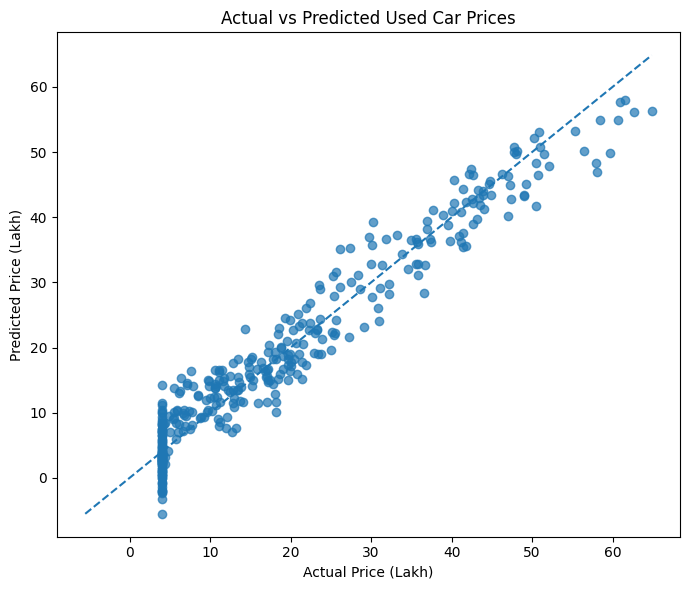

In [ ]:
# -----------------------------
# 19. Actual vs Predicted Prices
# -----------------------------

comparison = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": final_predictions
})

print("\nActual vs Predicted Prices:")
display(comparison.head(10))


plt.figure(figsize=(7, 6))

plt.scatter(
    y_test,
    final_predictions,
    alpha=0.7
)

plt.xlabel("Actual Price (Lakh)")
plt.ylabel("Predicted Price (Lakh)")
plt.title("Actual vs Predicted Used Car Prices")

# Perfect prediction reference line
min_price = min(y_test.min(), final_predictions.min())
max_price = max(y_test.max(), final_predictions.max())

plt.plot(
    [min_price, max_price],
    [min_price, max_price],
    linestyle="--"
)

plt.tight_layout()
plt.show()


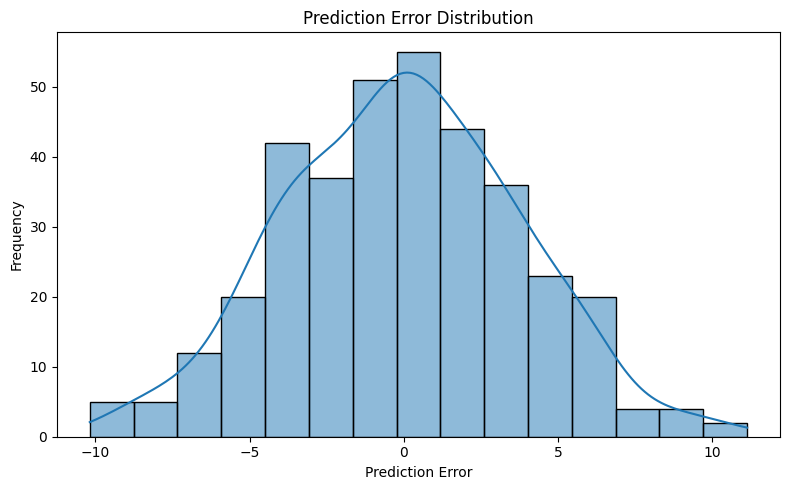

In [ ]:
# -----------------------------
# 20. Prediction Error Analysis
# -----------------------------

errors = y_test.values - final_predictions

plt.figure(figsize=(8, 5))

sns.histplot(errors, kde=True)

plt.title("Prediction Error Distribution")
plt.xlabel("Prediction Error")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

In [ ]:
# -----------------------------
# 21. Final Summary
# -----------------------------

print("\n" + "=" * 60)
print("PROJECT SUMMARY")
print("=" * 60)

print(f"Dataset size after cleaning: {df.shape}")
print(f"Number of features: {X.shape[1]}")
print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples: {X_test.shape[0]}")

print(f"\nSelected Model: {best_model_name}")
print(f"MAE: {final_mae:.2f}")
print(f"RMSE: {final_rmse:.2f}")
print(f"R² Score: {final_r2:.3f}")

print("\nProject completed successfully.")


PROJECT SUMMARY
Dataset size after cleaning: (1800, 14)
Number of features: 12
Training samples: 1440
Testing samples: 360

Selected Model: Linear Regression
MAE: 3.04
RMSE: 3.80
R² Score: 0.942

Project completed successfully.
